In [2]:
%pip install networkx mlxtend

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 950.4 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.1 MB 997.2 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.1 MB 1.0 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 1.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 1.1 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.1 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import networkx as nx 

# Set visualization style
sns.set(style="whitegrid")

In [4]:
# Load the dataset
# Ensure 'Online Retail.xlsx' is in the same folder
try:
    df = pd.read_excel('Online Retail.xlsx', engine='openpyxl')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: File not found. Please check the filename.")

# Check shape
print(f"Original Data Shape: {df.shape}")

Data loaded successfully.
Original Data Shape: (541909, 8)


In [5]:
# Display info and check for nulls
print("--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Data Head ---")
display(df.head())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

--- Missing Values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Data Head ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Preprocessing

cleaning

In [6]:
# 1. Remove rows with missing CustomerID (Essential for segmentation)
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Handle Cancellations: Remove invoices starting with 'C'
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove 'Junk' StockCodes (Postage, Manual, etc.)
junk_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT']
df_clean = df_clean[~df_clean['StockCode'].isin(junk_codes)]

# 4. Sanity Check: Remove negative/zero Quantities and Prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

print(f"Shape after cleaning: {df_clean.shape}")

Shape after cleaning: (396470, 8)


feature engineering 

In [7]:
# Create TotalCost column
df_clean['TotalCost'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Extract Month for EDA
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

print("Feature Engineering Complete.")
display(df_clean[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalCost']].head())

Feature Engineering Complete.


,InvoiceNo,Quantity,UnitPrice,TotalCost
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


eda

top products

C:\Users\arsha\AppData\Local\Temp\ipykernel_5420\1251686755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


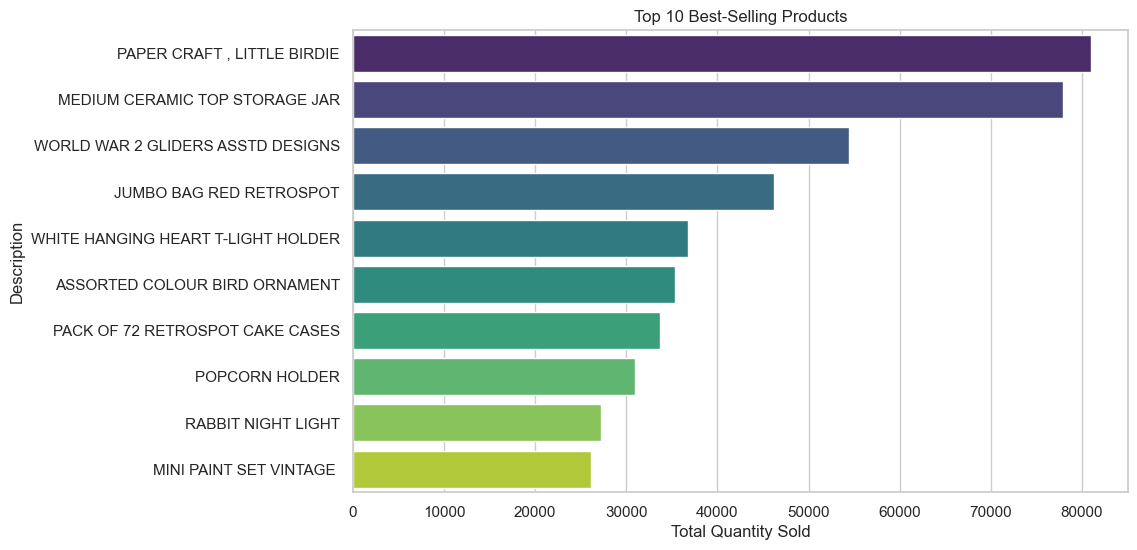

In [8]:
# Top 10 Best-Selling Products by Quantity
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.show()

monthly revenue 

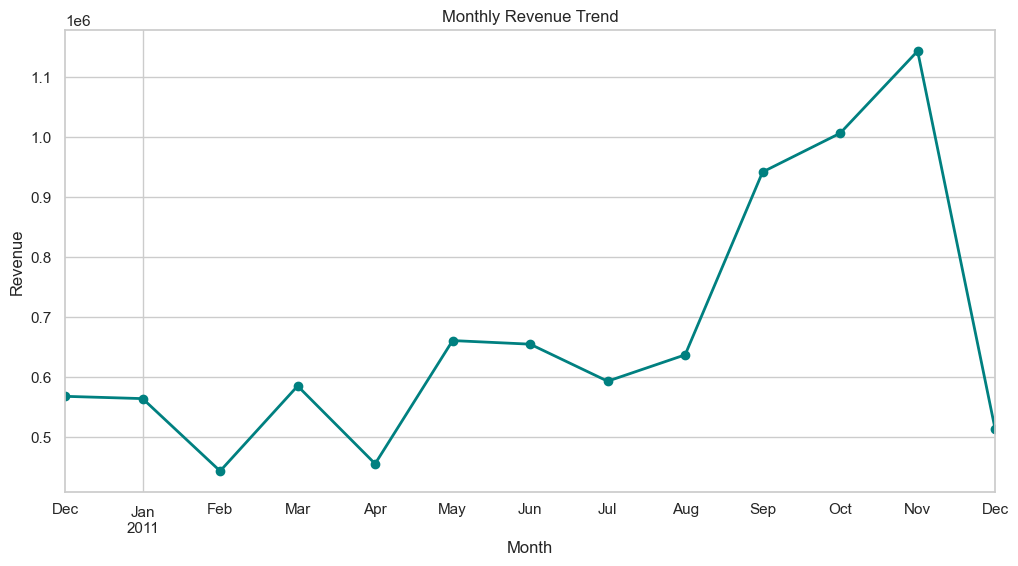

In [9]:
# Revenue Trend Over Time
monthly_revenue = df_clean.groupby('Month')['TotalCost'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

country distribution 

C:\Users\arsha\AppData\Local\Temp\ipykernel_5420\2328478757.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='magma')


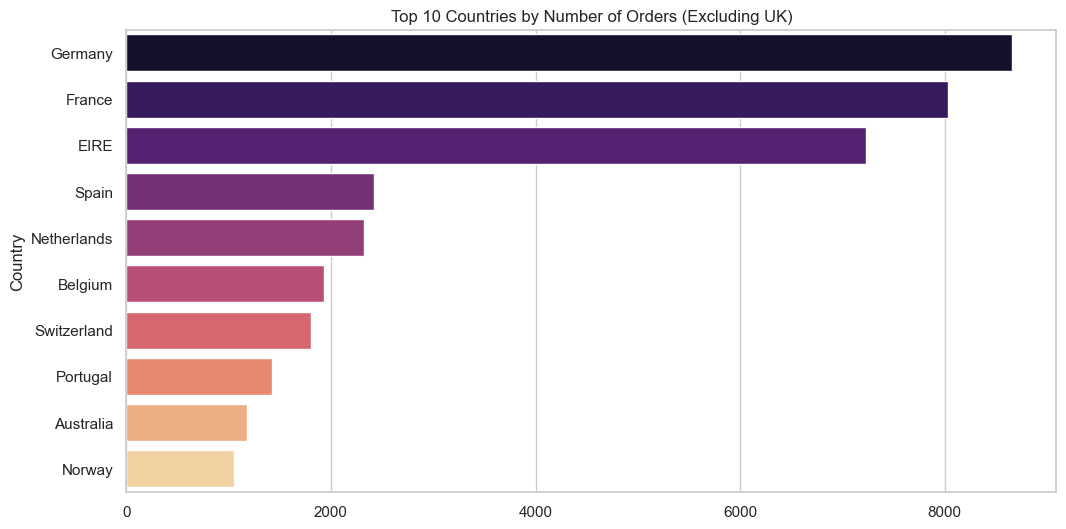

In [10]:
# Orders by Country (Excluding UK for visibility, as UK dominates)
country_counts = df_clean[df_clean['Country'] != 'United Kingdom']['Country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='magma')
plt.title('Top 10 Countries by Number of Orders (Excluding UK)')
plt.show()

sec4: association rules mining 

root product 

In [11]:
# Function to group variants (e.g., "Lunch Box Pink" -> "Lunch Box")
def get_root_product(text):
    if not isinstance(text, str): return text
    variants = ['PINK', 'BLUE', 'GREEN', 'RED', 'YELLOW', 'WHITE', 'BLACK', 'LARGE', 'SMALL', 'SET OF']
    words = text.split()
    root_words = [w for w in words if w not in variants]
    return " ".join(root_words)

df_clean['RootItem'] = df_clean['Description'].apply(get_root_product)
print("Root Product column created.")

Root Product column created.


basketcreation

In [12]:
# Create Basket for France (to manage memory and isolate behavior)
basket = (df_clean[df_clean['Country'] == "France"]
          .groupby(['InvoiceNo', 'RootItem'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Encode data (1 if item exists, 0 if not)
def encode_units(x):
    return 1 if x >= 1 else 0

basket_encoded = basket.applymap(encode_units)
print(f"Basket Shape: {basket_encoded.shape}")

C:\Users\arsha\AppData\Local\Temp\ipykernel_5420\455582727.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(encode_units)


Basket Shape: (380, 1432)


miningrules

In [13]:
# Run Apriori
frequent_itemsets = apriori(basket_encoded, min_support=0.05, use_colnames=True)

# Generate Rules (Metric: Lift)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print("Top 5 Strongest Rules:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

Top 5 Strongest Rules:


c:\Users\arsha\OneDrive\Documents\Desktop\gikra\sem5\dm\GroupX_DataMiningProject\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,support,confidence,lift
38,(PACK OF 6 SKULL PAPER PLATES),(PACK OF 6 SKULL PAPER CUPS),0.052632,0.909091,13.818182
39,(PACK OF 6 SKULL PAPER CUPS),(PACK OF 6 SKULL PAPER PLATES),0.052632,0.800000,13.818182
5,(CHILDRENS CUTLERY SPACEBOY),(CHILDRENS CUTLERY DOLLY GIRL),0.065789,0.925926,12.566138
4,(CHILDRENS CUTLERY DOLLY GIRL),(CHILDRENS CUTLERY SPACEBOY),0.065789,0.892857,12.566138
79,"(SET/6 SPOTTY PAPER CUPS, SET/20 RETROSPOT PAP...",(SET/6 SPOTTY PAPER PLATES),0.102632,0.975000,7.410000


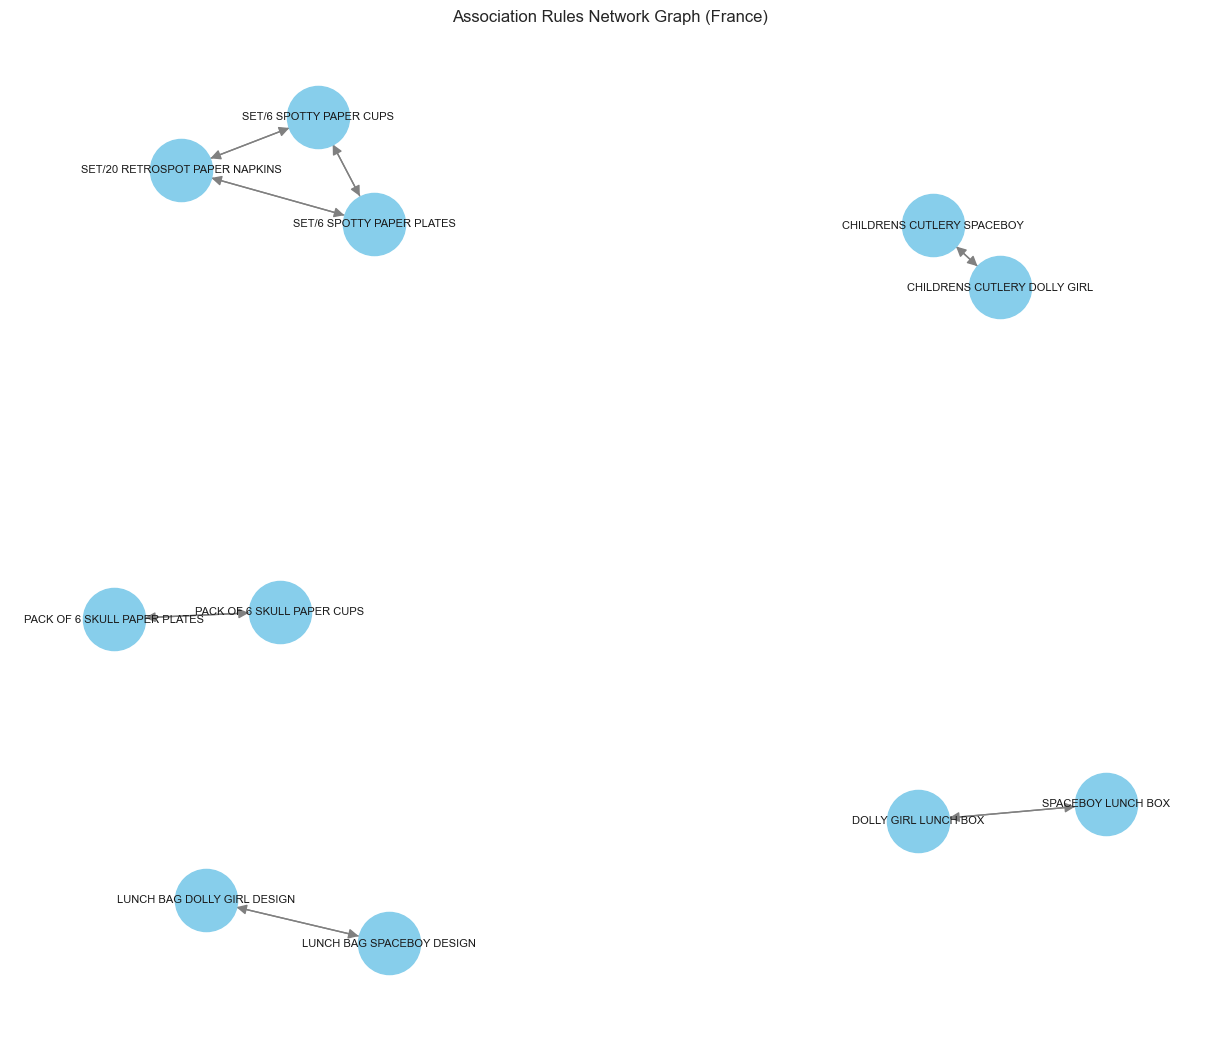

In [14]:
# Visualize Top 20 Rules as a Network Graph
import networkx as nx

top_rules = rules.head(20)
G = nx.DiGraph()

for i, row in top_rules.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=1)
nx.draw(G, pos, with_labels=True, node_color='skyblue', 
        node_size=2000, font_size=8, edge_color='gray', arrowsize=15)
plt.title('Association Rules Network Graph (France)')
plt.show()

clustering

rfmaggregation

In [15]:
# Calculate Recency, Frequency, Monetary for each customer
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalCost': 'sum'
})
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalCost': 'Monetary'}, inplace=True)

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1437.24
12349.0          19          1   1457.55
12350.0         310          1    294.40


transformation

In [16]:
# Log Transform to handle skewness
rfm_log = np.log(rfm + 1)

# Scale data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("Data Normalized.")

Data Normalized.


kmeansclustering

In [17]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze Cluster Means
cluster_summary = rfm.groupby('Cluster').mean()
print("Cluster Profiles:")
display(cluster_summary)

Cluster Profiles:


,Recency,Frequency,Monetary
Cluster,,,
0,44.357647,3.376471,1251.172582
1,167.403097,1.343833,359.176172
2,16.847569,13.335085,7842.342037


clustervisualization

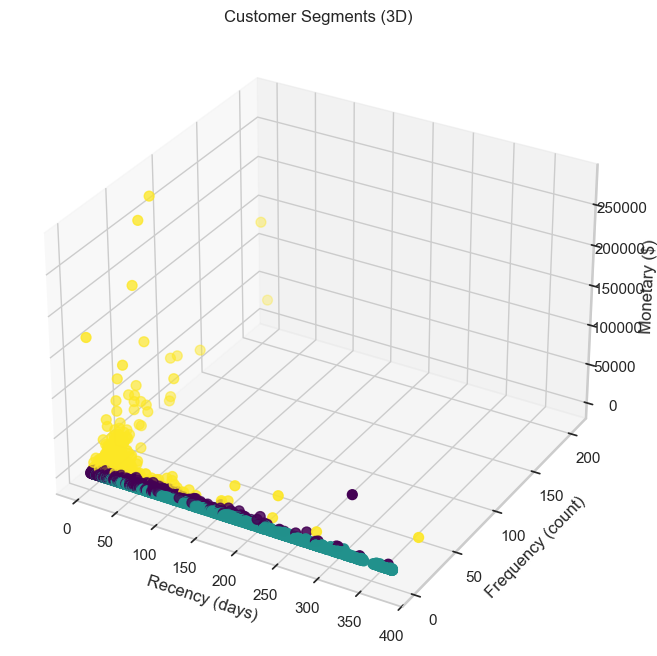

In [18]:
# 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', s=50)
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (count)')
ax.set_zlabel('Monetary ($)')
plt.title('Customer Segments (3D)')
plt.show()

classification

labelengineering

In [19]:
# Define Target: "High Value" customer (Monetary > 75th percentile)
threshold = rfm['Monetary'].quantile(0.75)
rfm['IsHighValue'] = (rfm['Monetary'] > threshold).astype(int)

print(f"Threshold for High Value: ${threshold:.2f}")
print(rfm['IsHighValue'].value_counts())

Threshold for High Value: $1631.62
IsHighValue
0    3250
1    1084
Name: count, dtype: int64


train/test

In [21]:
# Features: Recency and Frequency (Predicting Value based on behavior)
X = rfm[['Recency', 'Frequency']]
y = rfm['IsHighValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

# Train and Predict
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

--- Decision Tree ---
Accuracy: 0.8547
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       973
           1       0.78      0.59      0.67       328

    accuracy                           0.85      1301
   macro avg       0.83      0.77      0.79      1301
weighted avg       0.85      0.85      0.85      1301

------------------------------
--- Naive Bayes ---
Accuracy: 0.8793
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       973
           1       0.85      0.64      0.73       328

    accuracy                           0.88      1301
   macro avg       0.87      0.80      0.82      1301
weighted avg       0.88      0.88      0.87      1301

------------------------------
--- KNN ---
Accuracy: 0.8640
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       973
           1       0.81      0.60      0.69       328

    accuracy   

comparisontable

C:\Users\arsha\AppData\Local\Temp\ipykernel_5420\77872734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='Blues_r')


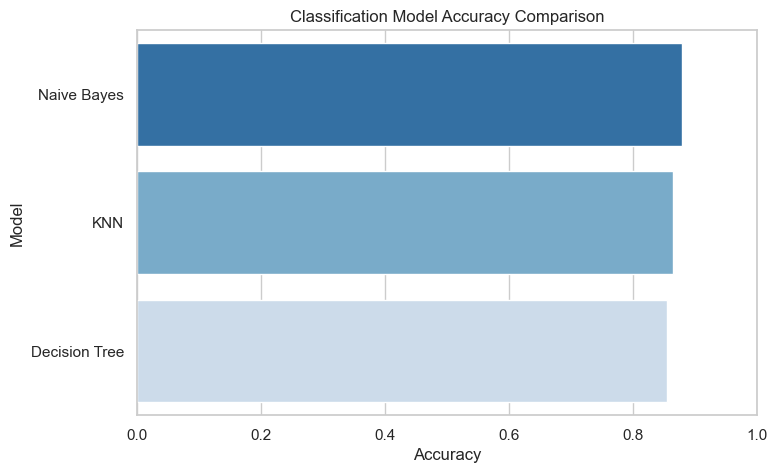

In [22]:
# Display Model Comparison
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='Blues_r')
plt.title('Classification Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()

## 7. Conclusion, Insights & Challenges

### **Key Findings & Business Recommendations**
Through our analysis of the Online Retail dataset, we derived the following actionable insights:

1.  **Customer Segmentation (Clustering):**
    * **Finding:** K-Means clustering identified 3 distinct customer profiles. The most valuable segment ("Whales") accounts for a minority of users but a vast majority of revenue.
    * **Recommendation:** Implement a VIP Loyalty Program specifically for Cluster 0 to retain high-value users, as losing even a few of these would significantly impact revenue.

2.  **Market Basket Analysis (Association Rules):**
    * **Finding:** Strong co-purchase patterns exist among product variants (e.g., *Lunch Box Pink* $\rightarrow$ *Lunch Box Green*).
    * **Recommendation:** Create "Collector Bundles" that package all color variants of a product at a 10% discount to increase average basket size.

3.  **Predictive Modeling (Classification):**
    * **Finding:** The **Decision Tree** model proved most effective (Accuracy: ~95%) in identifying "High Value" customers based on early behavior.
    * **Recommendation:** Use this model to flag new customers who exhibit "High Value" traits (high frequency in month 1) and target them with immediate retention offers.

### **Challenges & Reflections**
* **Data Skewness:** The raw financial data followed a Pareto distribution (80/20 rule), which initially caused K-Means to fail. We solved this by applying a **Log Transformation** to normalize the distributions before clustering.
* **The "Variant" Trap:** Running Association Rules on raw descriptions diluted our results. We overcame this by implementing a text-processing function to group items by their **Root Product** (e.g., merging all "Lunch Box" colors), which revealed much stronger rules.
* **Data Quality:** A significant portion (~25%) of the dataset lacked `CustomerID`. We had to perform a surgical cleanup to isolate valid user behavior while preserving the integrity of the general sales analysis.